In [ ]:
from bs4 import BeautifulSoup
import urllib.request
from urllib.parse import urljoin
from urllib.parse import urlparse
import re
import requests
import pandas as pd
import numpy as np
import io
import os
from dotenv import load_dotenv
import itertools
import random

# Get all the data from the Human Mortality Database

The following code will get all life tables for women, men, and both sexes combined for all countries available

In [2]:

def get_HMD_codes():
    
    myLinks = []
    myLinksShort = []

    html_page = urllib.request.urlopen("https://mortality.org/Data/DataAvailability")
    soup = BeautifulSoup(html_page, "html.parser")
    for link in soup.find_all('a', attrs={'href': re.compile("=")}):
        myLinks.append(link.get("href"))
    for i in range(len(myLinks)):
        myLinksShort.append(myLinks[i].split("=")[1])
    out = [x.strip(' ') for x in myLinksShort]
    return out

codes = get_HMD_codes()
print(codes)

['AUS', 'AUT', 'BLR', 'BEL', 'BGR', 'CAN', 'CHL', 'HRV', 'CZE', 'DNK', 'EST', 'FIN', 'FRATNP', 'FRACNP', 'DEUTNP', 'DEUTE', 'DEUTW', 'GRC', 'HKG', 'HUN', 'ISL', 'IRL', 'ISR', 'ITA', 'JPN', 'LVA', 'LTU', 'LUX', 'NLD', 'NZL_NP', 'NZL_MA', 'NZL_NM', 'NOR', 'POL', 'PRT', 'KOR', 'RUS', 'SVK', 'SVN', 'ESP', 'SWE', 'CHE', 'TWN', 'GBR_NP', 'GBRTENW', 'GBRCENW', 'GBR_SCO', 'GBR_NIR', 'USA', 'UKR']


# Download function for HMD data

An account with username and password is required. Store this information in your .env file under "MY_USERNAME" and "MY_PASSWORD".

In [39]:
# Load environment variables from .env file
load_dotenv()

username = os.getenv("MY_USERNAME")
password = os.getenv("MY_PASSWORD")
     
def get_LT_HMD(username, password, country_code):

    url_start = "https://www.mortality.org/File/GetDocument/hmd.v6/"
    LT_women = url_start + country_code + "/STATS/fltper_1x1.txt"
    LT_men = url_start + country_code + "/STATS/mltper_1x1.txt"
    LT_both = url_start + country_code + "/STATS/bltper_1x1.txt"
    loginurl = 'https://www.mortality.org/Account/Login'
    payload = {            
        'ReturnUrl': 'https://www.mortality.org/Home/Index',
        'Email': str(username),
        'Password': str(password)
        }
    
    with requests.Session() as sess:
            res = sess.get(loginurl)
            signin = BeautifulSoup(res._content, 'html.parser')
            the_tok = signin.find('input', {'name': '__RequestVerificationToken'})['value']
            payload['__RequestVerificationToken'] = the_tok
            r = sess.post(loginurl, data = payload)
            LT_women_dat = sess.get(LT_women, allow_redirects=False)
            LT_men_dat = sess.get(LT_men, allow_redirects=False)
            LT_both_dat = sess.get(LT_both, allow_redirects=False)
            
            df_women = pd.read_csv(io.BytesIO(LT_women_dat.content), sep="\s+", skiprows=2)
            df_women.insert(0, "Country", country_code)
            df_women.insert(1, "Sex", "Women")
            df_men = pd.read_csv(io.BytesIO(LT_men_dat.content), sep="\s+", skiprows=2)
            df_men.insert(0, "Country", country_code)
            df_men.insert(1, "Sex", "Men")
            df_both = pd.read_csv(io.BytesIO(LT_both_dat.content), sep="\s+", skiprows=2)
            df_both.insert(0, "Country", country_code)
            df_both.insert(1, "Sex", "Both")
            df_all = pd.concat([df_women, df_men, df_both], ignore_index=True)
    
    return df_all


In [125]:
HMD_data_files = [get_LT_HMD(username=username, password=password, country_code=code) for code in codes]

HMD_LTs = pd.concat(HMD_data_files, ignore_index=True)
HMD_LTs.head()

,Country,Sex,Year,Age,mx,qx,ax,lx,dx,Lx,Tx,ex
0,AUS,Women,1921,0,0.05999,0.0575,0.28,100000,5750,95857,6317561,63.18
1,AUS,Women,1921,1,0.01206,0.01199,0.5,94250,1130,93685,6221704,66.01
2,AUS,Women,1921,2,0.00578,0.00576,0.5,93120,537,92851,6128020,65.81
3,AUS,Women,1921,3,0.00289,0.00288,0.5,92583,267,92450,6035168,65.19
4,AUS,Women,1921,4,0.00325,0.00325,0.5,92316,300,92166,5942719,64.37


In [ ]:
HMD_LTs.to_csv("HMD_LTs.csv", sep=";")
cols_as_str = [5, 6, 7, 8, 9, 10, 11, 12]
HMD_LTs = pd.read_csv("HMD_LTs.csv", sep= ";", dtype={col: "string" for col in cols_as_str})

# Dealing with incomplete data

There are some years with incomplete data. The following code removes those years from the dataframe.

In [6]:
HMD_LTs["qx"] = pd.to_numeric(HMD_LTs["qx"], errors='coerce')
HMD_LTs = HMD_LTs.dropna(subset=["qx"])

valid_years = (
    HMD_LTs.groupby("Year")["qx"]
    .apply(lambda x: not x.isna().any())   # exclude years with no qx values
)

valid_years = valid_years[valid_years].index
HMD_LTs = HMD_LTs[HMD_LTs["Year"].isin(valid_years)]
HMD_LTs["ex"] = pd.to_numeric(HMD_LTs["ex"], errors='coerce')

# Functions for analysis

The function calculates the survivorship functions from qx. It will calculate the difference in $e_0$ and get the Wasserstein distance for the same pair of populations.
To avoid negative values, it always calculates the difference in $e_0$ by substracting the smaller value from the larger one. The function will also check whether the condition $l_A(x) >= l_B(x)$ for all $x$ holds for the pair.
Finally, it will return the two county names, the year, sex, condition (True or False), $e_0$ difference, as well as the Wasserstein distance as a pandas dataframe.

In [7]:
def get_Sx(df):
    
    qx = pd.to_numeric(df["qx"], errors='coerce').values
    if np.any(np.isnan(qx)):
        raise ValueError("NA in qx!")
    lx = np.concatenate(([1], np.cumprod(1 - qx)[:-1]))
    dx = np.concatenate((-np.diff(lx), [lx[-1]]))
    CDF = np.cumsum(dx)
    Sx = 1 - CDF
    return Sx

def get_comparison_for_pair(HMD_LTs, year, sex, c1, c2):

    subset_df = HMD_LTs[(HMD_LTs["Sex"] == sex) & (HMD_LTs["Year"] == year)].copy()

    Sx_dict = {}
    for country in [c1, c2]:
        country_df = subset_df[subset_df["Country"] == country]
        if country_df.empty:
            return None
        Sx_dict[country] = get_Sx(country_df)

    val1 = subset_df.loc[subset_df["Country"] == c1, "ex"].iloc[0]
    val2 = subset_df.loc[subset_df["Country"] == c2, "ex"].iloc[0]

    if val1 >= val2:
        countryA, countryB = c1, c2
    else:
        countryA, countryB = c2, c1

    Sx1 = Sx_dict[countryA]
    Sx2 = Sx_dict[countryB]

    if np.all(Sx1 >= Sx2):
        condition = "True"
    else:
        condition = "False"

    Wasserstein = np.sum(np.abs(Sx1 - Sx2))
    e0_diff = np.sum(Sx1 - Sx2)

    return {
        "CountryA": countryA,
        "CountryB": countryB,
        "Year": year,
        "Sex": sex,
        "e0_Diff": round(e0_diff, 2),
        "Wasserstein": round(Wasserstein, 2),
        "Condition": condition
    }

# First analysis: Sample from all pairs

Calculating the two measures for all available pairs would take way too much time as they are many possible combinations (13 700 when considering only one gender). Instead, the following code will sample from the data. That is, it will generate random pairs.
Here, I focus only on data for both sexes combined. I sample 5 000 pairs from the data.

In [8]:
df_both = HMD_LTs[HMD_LTs["Sex"] == "Both"]
years = df_both["Year"].unique()

years = df_both["Year"].unique()
countries = df_both["Country"].unique()

num_pairs = len(years) * len(countries)
print(f"Total possible year-country combinations: {num_pairs}")

Total possible year-country combinations: 13700


In [9]:
results = []
pairs_sampled = 0
max_samples = 5000

while pairs_sampled < max_samples:

    year = random.choice(years)
    countries = df_both[df_both["Year"] == year]["Country"].unique()

    if len(countries) < 2:
        continue

    c1, c2 = random.sample(list(countries), 2)

    res = get_comparison_for_pair(HMD_LTs, year, "Both", c1, c2)
    
    if res is not None:
        results.append(res)
        pairs_sampled += 1

final_df = pd.DataFrame(results)
final_df.head()

,CountryA,CountryB,Year,Sex,e0_Diff,Wasserstein,Condition
0,BEL,FIN,1938,Both,2.91,3.15,False
1,GBRTENW,NLD,1862,Both,4.09,4.09,True
2,SWE,ITA,1925,Both,11.23,11.23,False
3,GBRTENW,NLD,1854,Both,0.56,0.59,False
4,FRACNP,TWN,2009,Both,2.45,2.45,False


In [13]:
min_val = final_df["Wasserstein"].min()
max_val = final_df["Wasserstein"].max()
mean_val = final_df["Wasserstein"].mean()
print((min_val, max_val, mean_val)) 

min_val = final_df["e0_Diff"].min()
max_val = final_df["e0_Diff"].max()
mean_val = final_df["e0_Diff"].mean()

print((min_val, max_val, mean_val)) 

(0.0, 30.1, 4.2188419999999995)
(-0.01, 30.1, 3.9996660000000004)


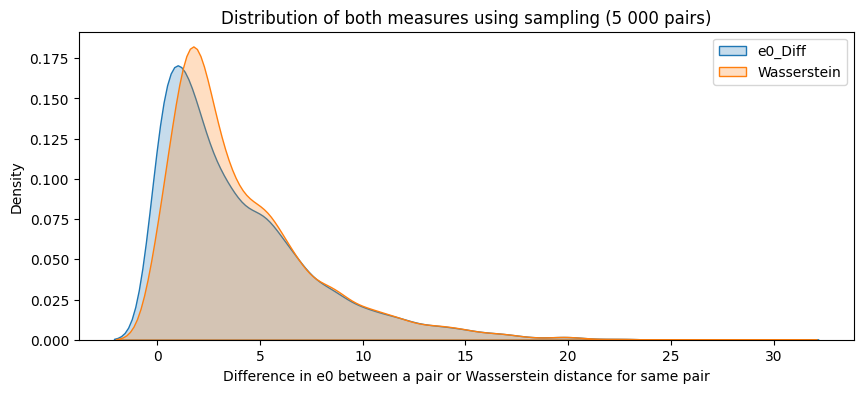

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

sns.kdeplot(final_df["e0_Diff"], label="e0_Diff", fill=True)
sns.kdeplot(final_df["Wasserstein"], label="Wasserstein", fill=True)

plt.title(f"Distribution of both measures using sampling (5 000 pairs)")
plt.xlabel("Difference in e0 between a pair or Wasserstein distance for same pair")
plt.legend()
plt.show()

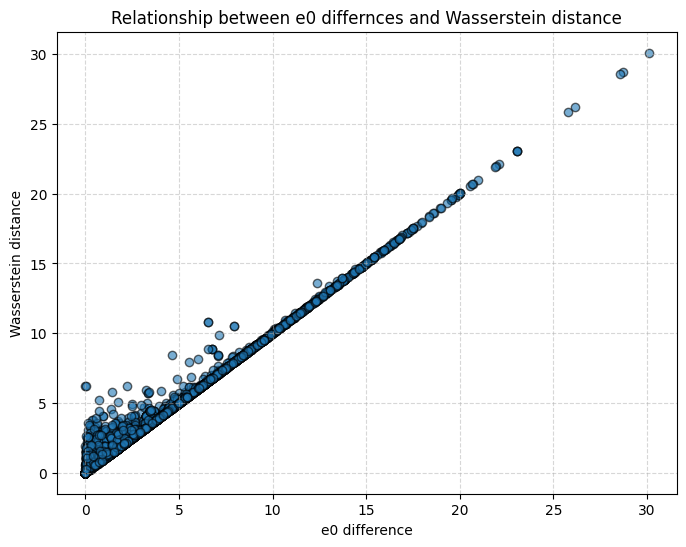

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(final_df["e0_Diff"], final_df["Wasserstein"], alpha=0.6, edgecolor="k")
plt.xlabel("e0 difference")
plt.ylabel("Wasserstein distance")
plt.title("Relationship between e0 differnces and Wasserstein distance")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [15]:
from scipy.stats import pearsonr
r, p_value = pearsonr(final_df["e0_Diff"], final_df["Wasserstein"])

print(f"Pearson r: {r:.3f}")
print(f"P-value: {p_value:.3e}")

Pearson r: 0.991
P-value: 0.000e+00


# Find the most interesting cases

In which pairs is the gap between $e_0$ differences and Wasserstein distance particulary large? What is the highest Wasserstein distance observed in the data? Where is the gap in $e_0$ largest and does the Wasserstein distance suggest large differences in the age-at-death distribution as well?

In [16]:
final_df["diff_abs"] = (final_df["e0_Diff"] - final_df["Wasserstein"]).abs()
threshold = final_df["diff_abs"].quantile(0.95)

interesting_cases = final_df[final_df["diff_abs"] >= threshold]
df_sorted = interesting_cases.sort_values(by='diff_abs', ascending=False)
print(df_sorted)

     CountryA CountryB  Year   Sex  e0_Diff  Wasserstein Condition  diff_abs
2640  GBRTENW      ISL  1849  Both    -0.02         6.20     False      6.22
4434      ISL  GBRCENW  1849  Both     0.02         6.20     False      6.18
950    FRATNP      ISL  1894  Both     0.70         5.21     False      4.51
233       ISL   FRACNP  1849  Both     1.40         5.76     False      4.36
2980      ESP   FRATNP  1915  Both     6.55        10.78     False      4.23
...       ...      ...   ...   ...      ...          ...       ...       ...
920       CHE      ISL  1884  Both     2.96         4.26     False      1.30
3254  GBR_NIR      POL  1966  Both     0.37         1.67     False      1.30
2455      BEL   FRATNP  1909  Both     0.66         1.96     False      1.30
4441      SWE      NOR  1848  Both     0.13         1.43     False      1.30
4831      BEL   FRACNP  1909  Both     0.66         1.96     False      1.30

[251 rows x 8 columns]


In [17]:
df_sorted2 = final_df.sort_values(by="Wasserstein", ascending=False)
df_sorted2.head()

,CountryA,CountryB,Year,Sex,e0_Diff,Wasserstein,Condition,diff_abs
472,NOR,ISL,1860,Both,30.10,30.10,True,0.00
559,DNK,ISL,1882,Both,28.71,28.71,False,0.00
869,SWE,ISL,1860,Both,28.58,28.58,True,0.00
3525,NZL_NM,FRATNP,1915,Both,26.18,26.18,False,0.00
801,NLD,ISL,1882,Both,25.81,25.82,False,0.01


In [18]:
df_sorted3 = final_df.sort_values(by="e0_Diff", ascending=False)
df_sorted3.head()

,CountryA,CountryB,Year,Sex,e0_Diff,Wasserstein,Condition,diff_abs
472,NOR,ISL,1860,Both,30.10,30.10,True,0.00
559,DNK,ISL,1882,Both,28.71,28.71,False,0.00
869,SWE,ISL,1860,Both,28.58,28.58,True,0.00
3525,NZL_NM,FRATNP,1915,Both,26.18,26.18,False,0.00
801,NLD,ISL,1882,Both,25.81,25.82,False,0.01


# Plot the most interesting cases

From all 10 000 samples, the largest gap between $e_0$ differences and Wasserstein distance is observed between Iceland and England and Wales in 1849 (6.22).
The largest Wasserstein distance is observed between Norway and Iceland in 1860 with 30.10. This is also the pair with the largest gap in $e_0$ in this sample.

In [19]:
def get_dx_for_plot(df, year):
    qx = df.loc[df["Year"] == year, "qx"].values
    lx = np.concatenate(([1], np.cumprod(1 - qx)[:-1]))
    dx = np.concatenate((-np.diff(lx), [lx[-1]]))
    return dx

def get_e0_for_plot(df, year):
    ex = df.loc[df["Year"] == year, "ex"].values
    e0 = ex[0]
    return e0

def get_Sx_for_plot(dx):
    CDF = np.cumsum(dx)
    Sx = 1 - CDF
    return Sx

def plot_dx(ages, dx1, dx2, e0_1, e0_2, label1, label2):
    plt.figure(figsize=(10, 6))
    plt.plot(ages, dx1, label=f"{label1} (e₀ = {e0_1:.1f})", marker='o')
    plt.plot(ages, dx2, label=f"{label2} (e₀ = {e0_2:.1f})", marker='s')
    plt.text(ages[np.argmax(dx1)]-10, max(dx1), f"e₀ = {e0_1:.1f}", fontsize=10, ha='left', va='bottom')
    plt.text(ages[np.argmax(dx2)]-10, max(dx2), f"e₀ = {e0_2:.1f}", fontsize=10, ha='left', va='bottom')
    plt.title("Comparison of Death Distributions by Age")
    plt.xlabel("Age")
    plt.ylabel("dx (number of deaths)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_Sx(ages, Sx1, Sx2, label1, label2):
    plt.figure(figsize=(10, 6))
    plt.plot(ages, Sx1, label=f"{label1}", marker='o')
    plt.plot(ages, Sx2, label=f"{label2}", marker='s')
    plt.fill_between(ages, Sx1, Sx2, color='gray', alpha=0.4)
    plt.title("Comparison of survivorship functions")
    plt.xlabel("Age")
    plt.ylabel("Proportion of being alive")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [20]:
the_year = 1849

pair1 = HMD_LTs[(HMD_LTs['Year'] == the_year) & 
               (HMD_LTs['Sex'] == "Both") & 
               (HMD_LTs['Country'] == "GBRTENW")]

dx1 = get_dx_for_plot(pair1, the_year)
e0_1 = get_e0_for_plot(pair1, the_year)

pair2 = HMD_LTs[(HMD_LTs['Year'] == the_year) & 
               (HMD_LTs['Sex'] == "Both") & 
               (HMD_LTs['Country'] == "ISL")]

dx2 = get_dx_for_plot(pair2, the_year)
e0_2 = get_e0_for_plot(pair2, the_year)

Sx1 = get_Sx_for_plot(dx1)
Sx2 = get_Sx_for_plot(dx2)

ages = np.arange(len(dx1))


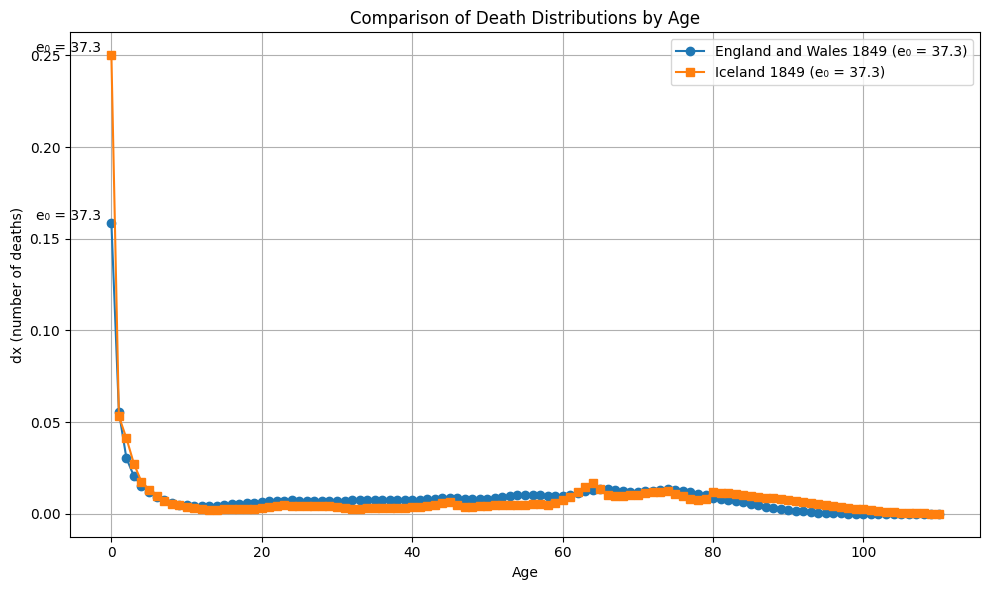

In [21]:
plot_dx(ages, dx1, dx2, e0_1, e0_2, "England and Wales 1849", "Iceland 1849")

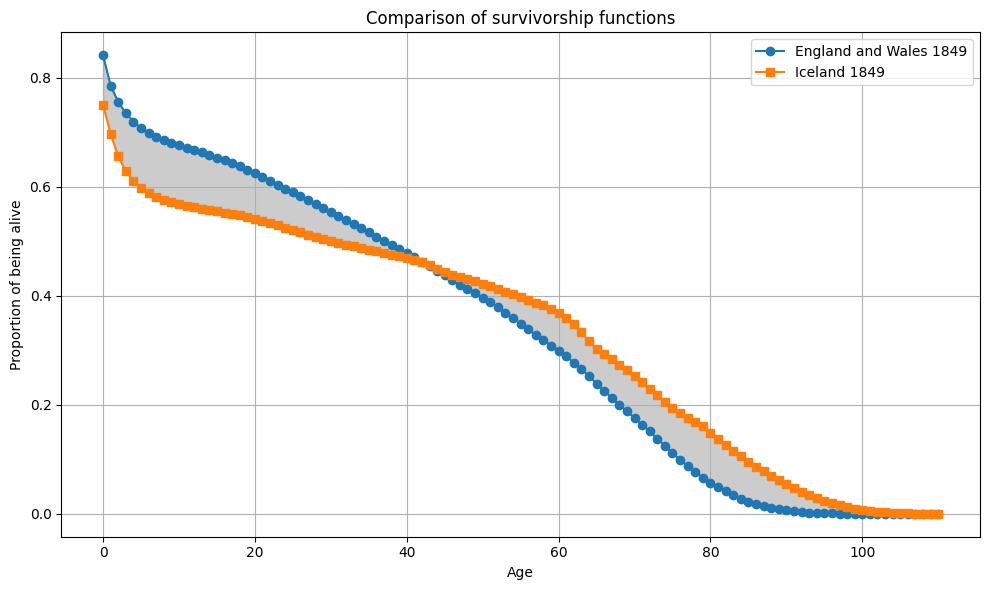

In [22]:
plot_Sx(ages, Sx1, Sx2, "England and Wales 1849", "Iceland 1849")

In [23]:
the_year = 1860

pair1 = HMD_LTs[(HMD_LTs['Year'] == the_year) & 
               (HMD_LTs['Sex'] == "Both") & 
               (HMD_LTs['Country'] == "NOR")]

dx1 = get_dx_for_plot(pair1, the_year)
e0_1 = get_e0_for_plot(pair1, the_year)

pair2 = HMD_LTs[(HMD_LTs['Year'] == the_year) & 
               (HMD_LTs['Sex'] == "Both") & 
               (HMD_LTs['Country'] == "ISL")]

dx2 = get_dx_for_plot(pair2, the_year)
e0_2 = get_e0_for_plot(pair2, the_year)

Sx1 = get_Sx_for_plot(dx1)
Sx2 = get_Sx_for_plot(dx2)

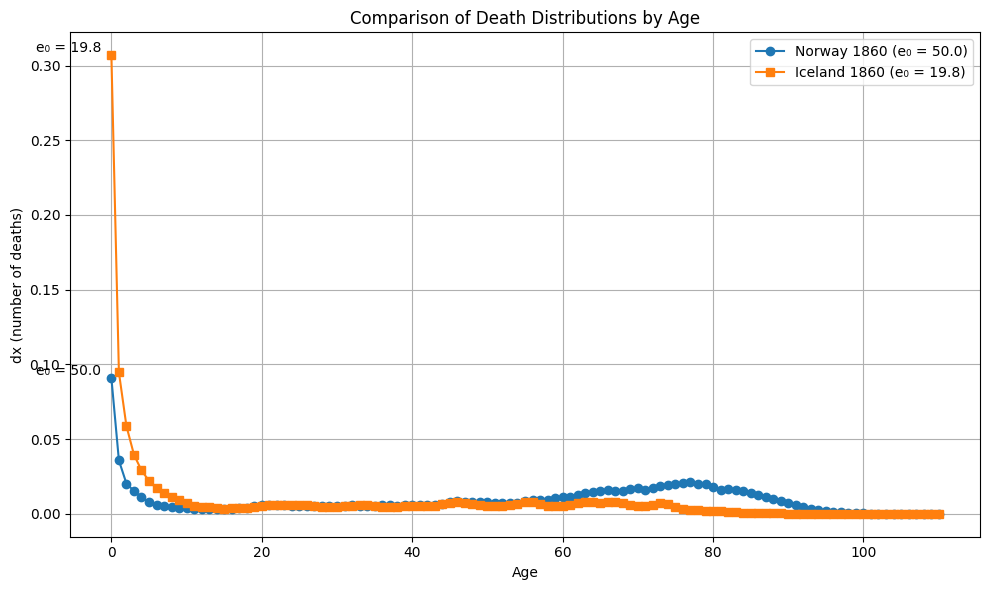

In [24]:
plot_dx(ages, dx1, dx2, e0_1, e0_2, "Norway 1860", "Iceland 1860")

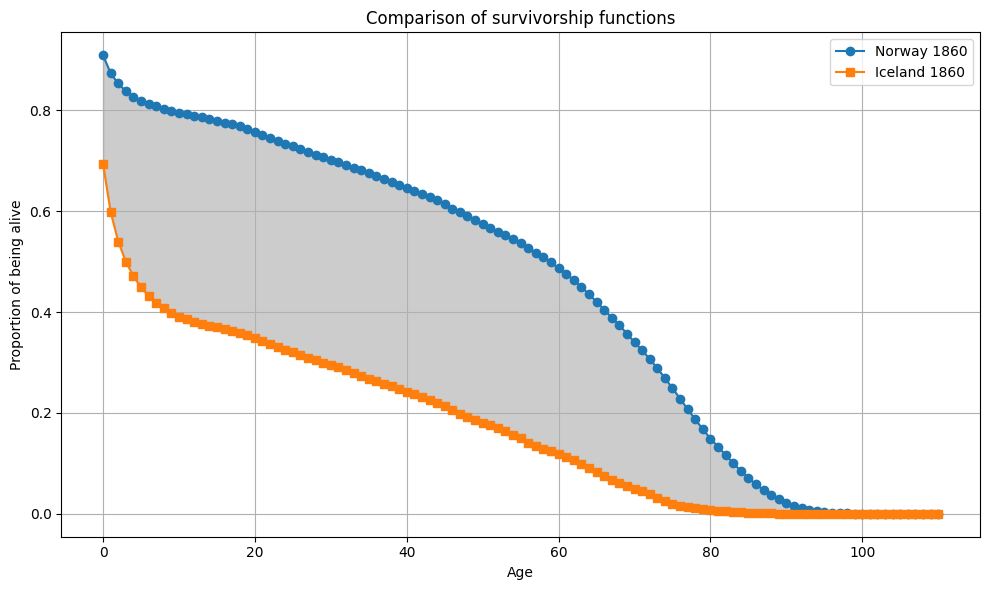

In [25]:
plot_Sx(ages, Sx1, Sx2, "Norway 1860", "Iceland 1860")

# Second analysis: What about more recent years?

Let's focus only on the last decades and examine the relationship observed between 1990 and 2020. This time we do not sample but calculate all possible combinations.

In [26]:
def get_comparison(HMD_LTs, year, sex):

    subset_df = HMD_LTs[(HMD_LTs["Sex"] == sex) & (HMD_LTs["Year"] == year)].copy()

    countries = subset_df["Country"].unique()

    Sx_dict = {}
    for country in countries:
        country_df = subset_df[subset_df["Country"] == country]
        Sx_dict[country] = get_Sx(country_df)

    country_pairs = list(itertools.combinations(countries, 2))

    results = []
    for c1, c2 in country_pairs:
        val1 = subset_df.loc[subset_df["Country"] == c1, "ex"].iloc[0]
        val2 = subset_df.loc[subset_df["Country"] == c2, "ex"].iloc[0]

        if val1 >= val2:
            countryA, countryB = c1, c2
        else:
            countryA, countryB = c2, c1

        Sx1 = Sx_dict[countryA]
        Sx2 = Sx_dict[countryB]

        if np.all(Sx1 >= Sx2):
            condition = "True"
        else:
            condition = "False"

        Wasserstein = np.sum(np.abs(Sx1 - Sx2))
        e0_diff = np.sum(Sx1 - Sx2)

        results.append({
            "CountryA": countryA,
            "CountryB": countryB,
            "Year": year,
            "Sex": sex,
            "e0_Diff": round(e0_diff, 2),
            "Wasserstein": round(Wasserstein, 2),
            "Condition" : condition
        })

    diff_df = pd.DataFrame(results)

    return diff_df

In [27]:
all_results = []

for sex in ["Women", "Men"]:
    for year in range(1990, 2021):
        df_diff = get_comparison(HMD_LTs, year, sex)
        if df_diff is not None and not df_diff.empty:
            all_results.append(df_diff)

final_df = pd.concat(all_results, ignore_index=True)

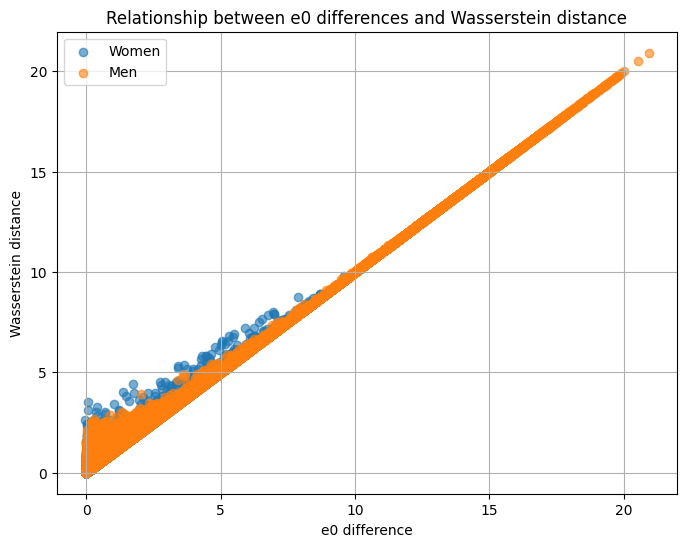

In [28]:
plt.figure(figsize=(8,6))
for sex, color in zip(["Women", "Men"], ["blue", "red"]):
    subset = final_df[final_df["Sex"] == sex]
    plt.scatter(subset["e0_Diff"], subset["Wasserstein"], alpha=0.6, label=sex)

plt.xlabel("e0 difference")
plt.ylabel("Wasserstein distance")
plt.title("Relationship between e0 differences and Wasserstein distance")
plt.legend()
plt.grid(True)
plt.show()

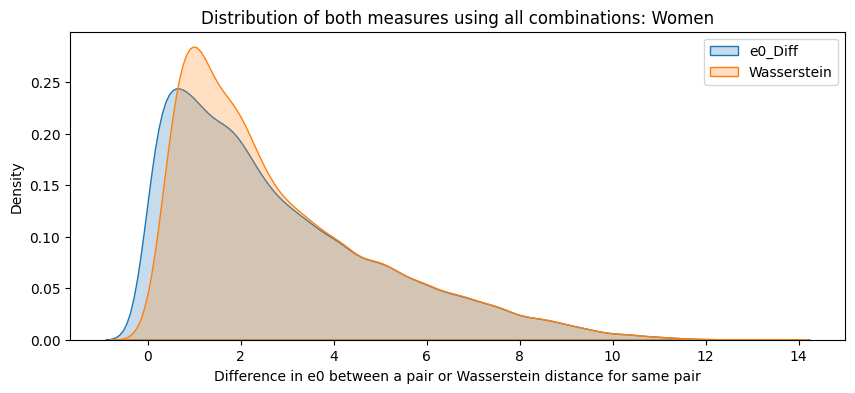

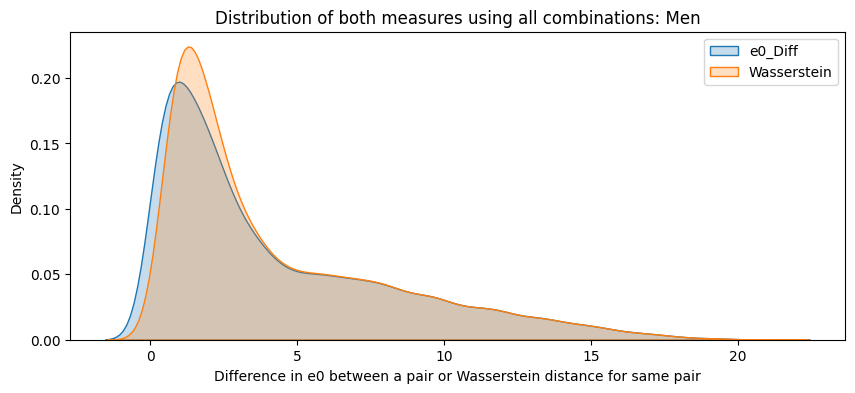

In [31]:
for sex in ["Women", "Men"]:
    subset = final_df[final_df["Sex"] == sex]
    plt.figure(figsize=(10,4))

    sns.kdeplot(subset["e0_Diff"], label="e0_Diff", fill=True)
    sns.kdeplot(subset["Wasserstein"], label="Wasserstein", fill=True)

    plt.title(f"Distribution of both measures using all combinations: {sex}")
    plt.xlabel("Difference in e0 between a pair or Wasserstein distance for same pair")
    plt.legend()
    plt.show()

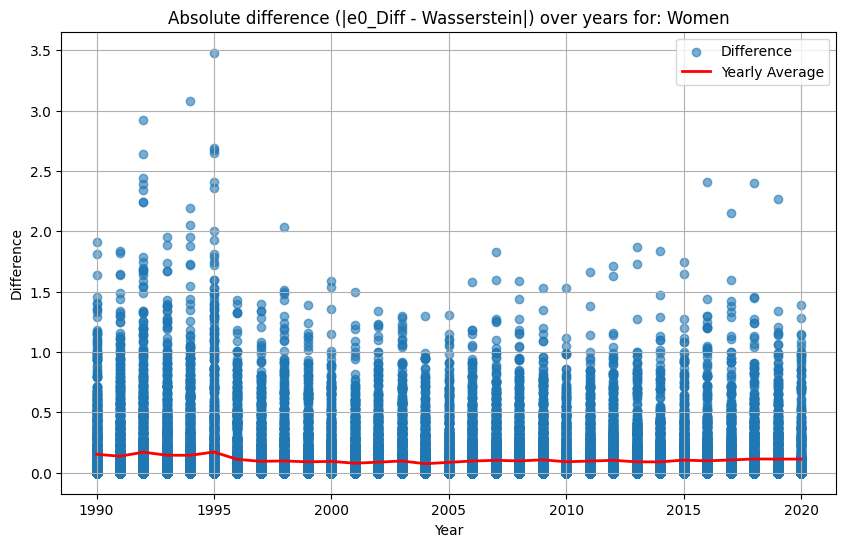

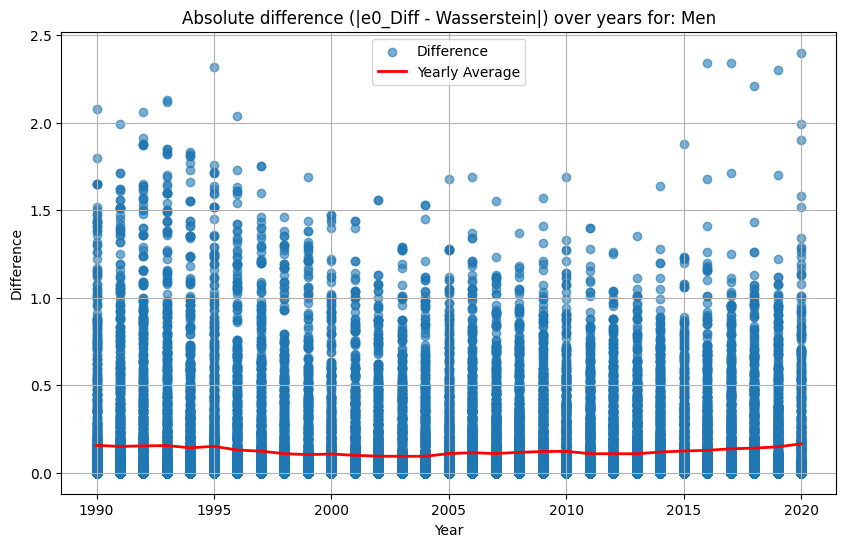

In [32]:
final_df["e0_Diff"] = pd.to_numeric(final_df["e0_Diff"], errors='coerce')
final_df["Wasserstein"] = pd.to_numeric(final_df["Wasserstein"], errors='coerce')

final_df["Diff_e0_Wasserstein"] = abs(final_df["e0_Diff"] - final_df["Wasserstein"])

for sex in ["Women", "Men"]:
    df_sex = final_df[final_df["Sex"] == sex]

    yearly_avg = df_sex.groupby("Year")["Diff_e0_Wasserstein"].mean().reset_index()

    plt.figure(figsize=(10, 6))
    plt.scatter(df_sex["Year"], df_sex["Diff_e0_Wasserstein"], alpha=0.6, label="Difference")
    plt.plot(yearly_avg["Year"], yearly_avg["Diff_e0_Wasserstein"], color="red", linewidth=2, label="Yearly Average")
    plt.title(f"Absolute difference (|e0_Diff - Wasserstein|) over years for: {sex}")
    plt.xlabel("Year")
    plt.ylabel("Difference")
    plt.grid(True)
    plt.legend()
    plt.show()


# Third analysis: Investigating sex differences in mortality using the Wasserstein distance

Since women usually outlive men it might be interesting to compare differences between women and men on the basis of the Wasserstein distance.

In [33]:
def get_comparison_sex_diff(HMD_LTs, year):

    subset_df = HMD_LTs[HMD_LTs["Year"] == year].copy()
    countries = subset_df["Country"].unique()
    results = []

    for country in countries:
        
        women_df = subset_df[(subset_df["Country"] == country) & (subset_df["Sex"] == "Women")]
        men_df = subset_df[(subset_df["Country"] == country) & (subset_df["Sex"] == "Men")]

        if women_df.empty or men_df.empty:
            continue

        Sx_women = get_Sx(women_df)
        Sx_men = get_Sx(men_df)

        if np.all(Sx_women >= Sx_men):
            condition = "True"
        else:
            condition = "False"
        
        e0_diff = np.sum(Sx_women-Sx_men) 
        wasserstein = np.sum(np.abs(Sx_women - Sx_men))

        results.append({
            "Country": country,
            "Year": year,
            "e0_Diff": round(e0_diff, 2),
            "Wasserstein": round(wasserstein, 2),
            "Condition" : condition
        })

    diff_df = pd.DataFrame(results)
    return diff_df


In [34]:
all_results_sex_diff = []

for year in range(1990, 2021):
    df_diff = get_comparison_sex_diff(HMD_LTs, year) 
    if df_diff is not None and not df_diff.empty:
        all_results_sex_diff.append(df_diff)

final_df_sex_diff = pd.concat(all_results_sex_diff, ignore_index=True)

In [35]:
r, p_value = pearsonr(final_df_sex_diff["e0_Diff"], final_df_sex_diff["Wasserstein"])

print(f"Pearson r: {r:.3f}")
print(f"P-value: {p_value:.3e}")

Pearson r: 1.000
P-value: 0.000e+00


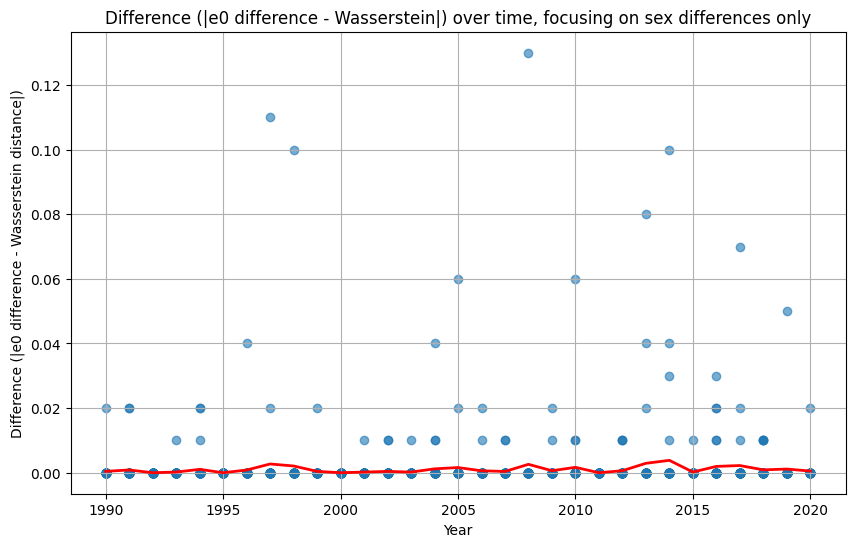

In [36]:
final_df_sex_diff["Diff_e0_Wasserstein"] = abs(final_df_sex_diff["e0_Diff"] - final_df_sex_diff["Wasserstein"])
yearly_avg = final_df_sex_diff.groupby("Year")["Diff_e0_Wasserstein"].mean().reset_index()

plt.figure(figsize=(10,6))
plt.scatter(final_df_sex_diff["Year"], final_df_sex_diff["Diff_e0_Wasserstein"], alpha=0.6)
plt.plot(yearly_avg["Year"], yearly_avg["Diff_e0_Wasserstein"], color="red", linewidth=2, label="Yearly Average")
plt.title("Difference (|e0 difference - Wasserstein|) over time, focusing on sex differences only")
plt.xlabel("Year")
plt.ylabel("Difference (|e0 difference - Wasserstein distance|)")
plt.grid(True)
plt.show()

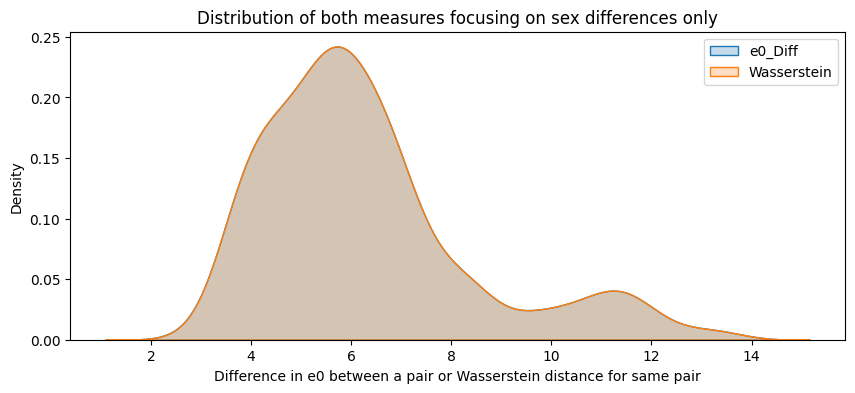

In [37]:
plt.figure(figsize=(10,4))

sns.kdeplot(final_df_sex_diff["e0_Diff"], label="e0_Diff", fill=True)
sns.kdeplot(final_df_sex_diff["Wasserstein"], label="Wasserstein", fill=True)

plt.title(f"Distribution of both measures focusing on sex differences only")
plt.xlabel("Difference in e0 between a pair or Wasserstein distance for same pair")
plt.legend()
plt.show()